# Real Data Analysis

* Data Sample: *753829*
* Type: *unwounded*
* Subtype: *Wound*
* X-number: *52*
* Y-number: *145*
* Nº points: *7468*


### 1. Imports and Configurations

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_context('notebook')
sns.set_style('white')
my_cmap = sns.color_palette("viridis", as_cmap=True)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import hdbscan

### 2. Import Data

In [12]:
file_path = 'Data/753829 IQ_fitting.csv'
df_import  = pd.read_csv(file_path)

z_parameters = ['total SAXS intensity', 'area under third order curve', 'D_period']
df = df_import.dropna(subset=z_parameters).copy()

df.head()

,x,y,total SAXS intensity,total_SAXS_norm_0_1,area under third order curve,collagen_third_norm_0_1,percentage_above_baseline,max_recorded_intensity,firstmoment,secondmoment,...,wMu,firstmoment_lu,secondmoment_lu,thirdmoment_lu,skewness_lu,D_period,peak_width,wp,peak_amplitude,fibril_radius
0,0,0,0.761302,0.256197,0.000000,1.000000e-09,35.318771,0.015390,0.291159,0.0849,...,0.015918,0.299098,0.0895,0.026758,-0.633265,63.041993,0.001,0.004760,1,560.272132
1,1,0,0.767918,0.258971,0.000000,1.000000e-09,14.286950,0.040639,0.274783,0.0755,...,0.187551,0.306105,0.0938,0.028730,2.599635,62.623109,0.001,0.056453,1,47.237054
2,2,0,0.753616,0.252974,0.000379,7.088826e-02,88.423642,0.033713,0.286602,0.0822,...,0.027755,0.295121,0.0871,0.025705,-0.084105,63.896800,0.001,0.008188,1,325.689598
3,3,0,0.757034,0.254407,0.000000,1.000000e-09,47.013759,0.027789,0.285605,0.0816,...,0.039592,0.290273,0.0843,0.024459,-0.324420,64.998469,0.001,0.011482,1,232.255007
4,4,0,0.757243,0.254495,0.000000,1.000000e-09,24.287431,0.018811,0.287495,0.0828,...,0.039592,0.288280,0.0831,0.023959,-0.404771,65.449847,0.001,0.011402,1,233.867889


### 3. Plots

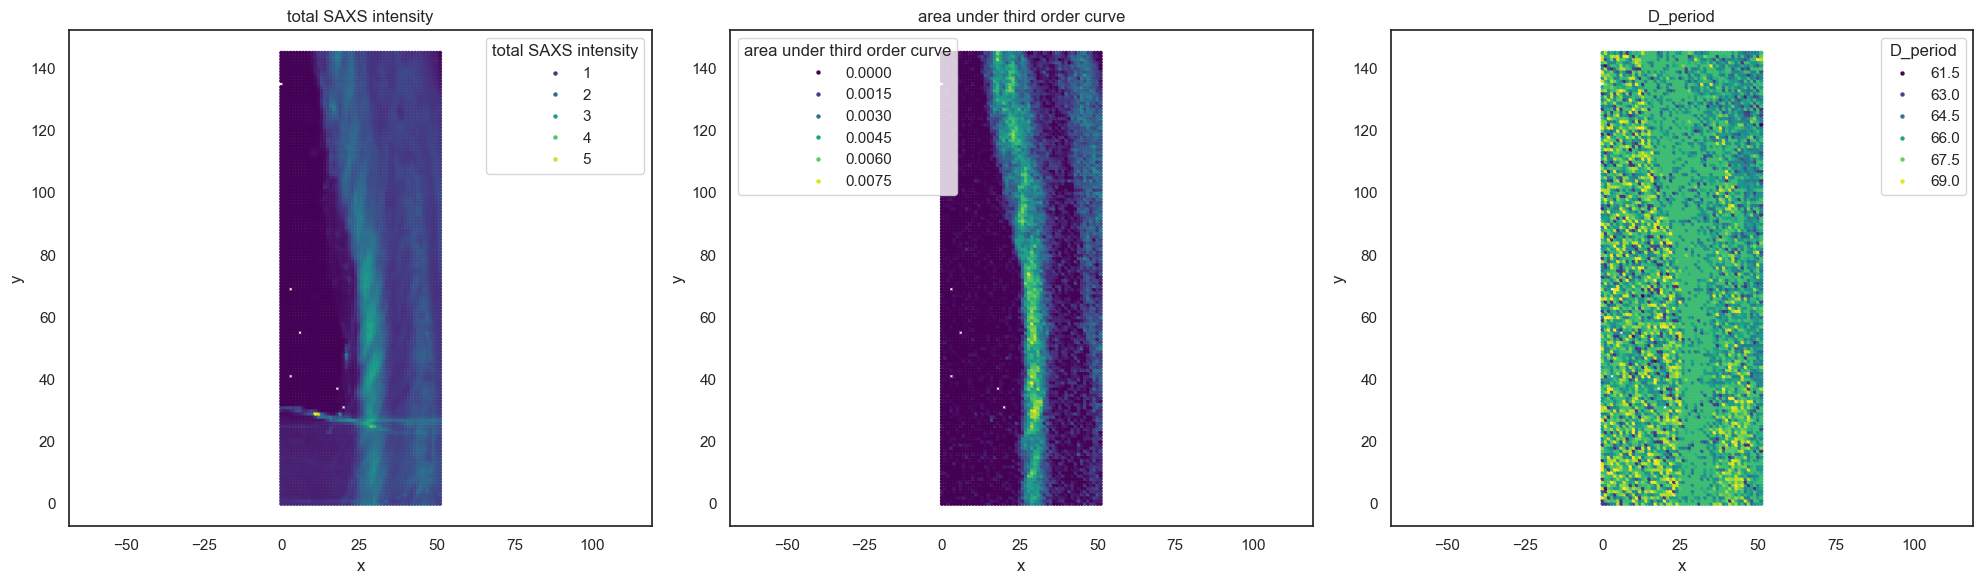

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, param in enumerate(z_parameters):
    sns.scatterplot(
        data=df,
        x='x',
        y='y',
        hue=param,
        palette=my_cmap,
        edgecolor='none',
        s=10,
        ax=axes[i]
    )

    axes[i].set_title(param)
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

### 4. Individual plots

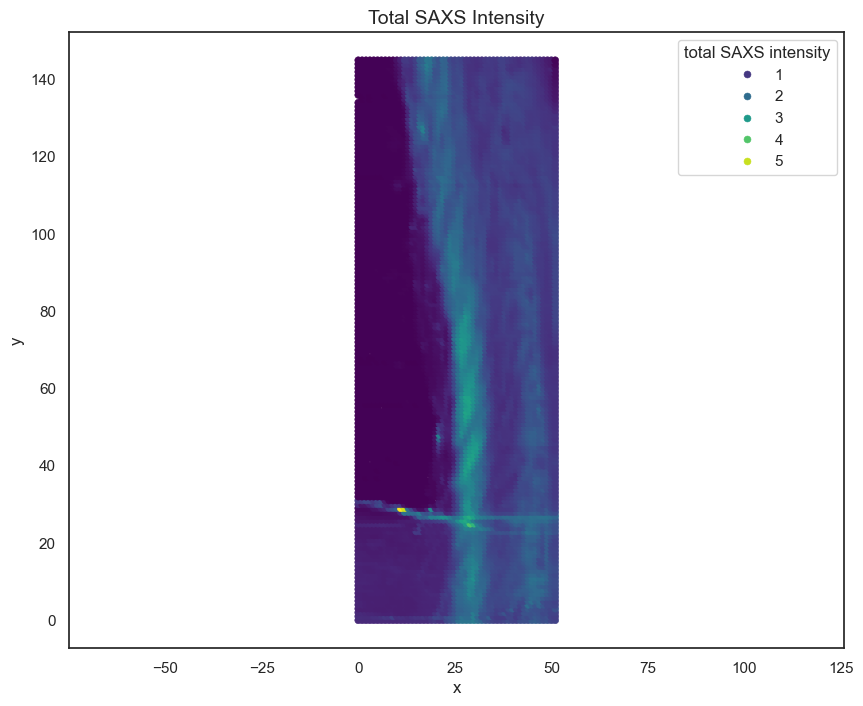

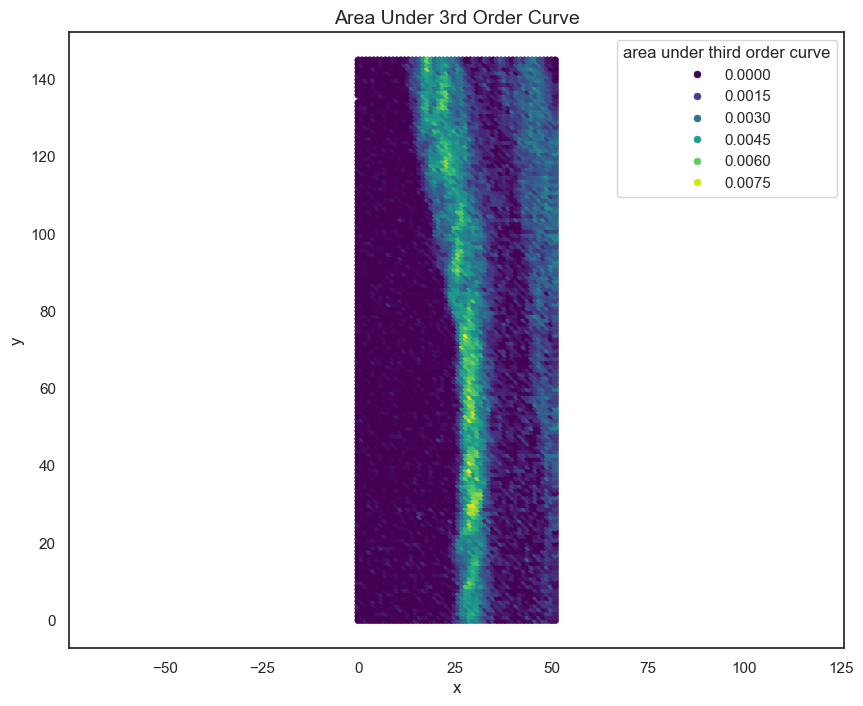

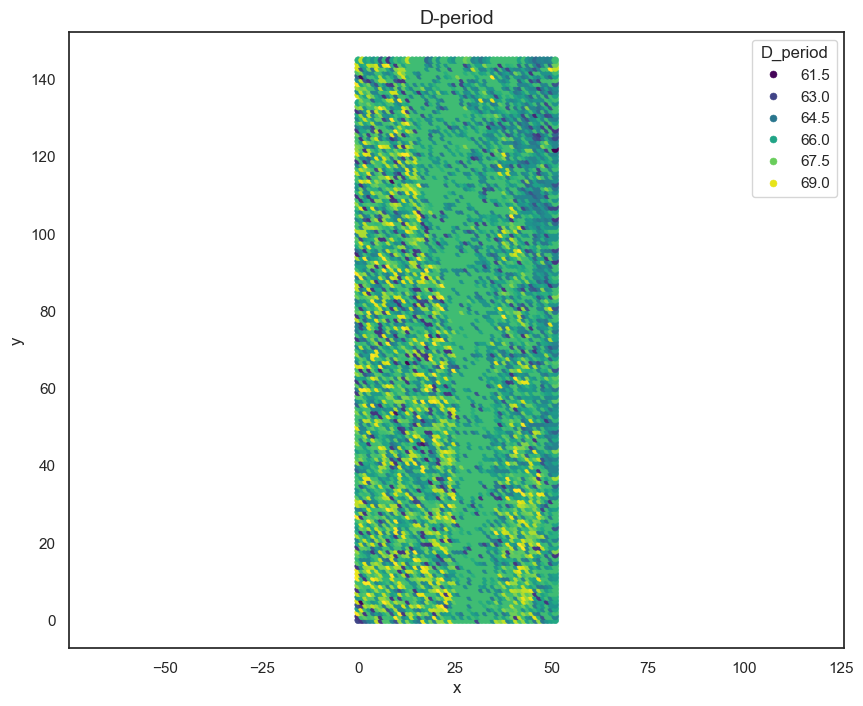

In [14]:
# Total SAXS Intensity
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='total SAXS intensity', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('Total SAXS Intensity', fontsize=14)
plt.axis('equal')
plt.show()

# Area Under 3rd Order Curve
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='area under third order curve', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('Area Under 3rd Order Curve', fontsize=14)
plt.axis('equal')
plt.show()

# D Period
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='x', 
    y='y', 
    hue='D_period', 
    palette=my_cmap,   
    edgecolor=None, 
    s=25
)
plt.title('D-period', fontsize=14)
plt.axis('equal')
plt.show()

### 5. Single-Sample Test

#### 5.1 Can HDBSCAN seperate anatomical layers for this one **unwounded** sample (like epidermis and dermis)?

Number of clusters found: 4


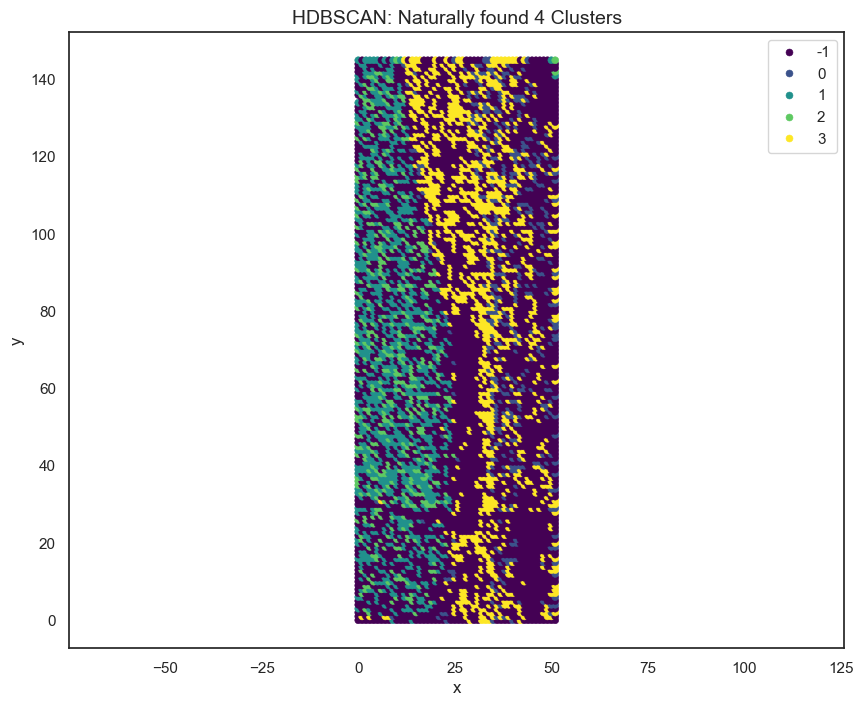

In [ ]:
# Filter original dataframe to only include the z_parameters
df_filtered = df[z_parameters]

# Scale the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_filtered)

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=10)
clusterer.fit(X_scaled)

num_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
print(f"Number of clusters found: {num_clusters}")

# Plotting the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue=clusterer.labels_,
    palette='viridis',
    edgecolor=None,
    s=25
)
plt.title(f'HDBSCAN: Naturally found {num_clusters} Clusters', fontsize=14)
plt.axis('equal')
plt.show()

#### 5.2 Can K-means seperate anatomical layers for this **unwounded** sample?

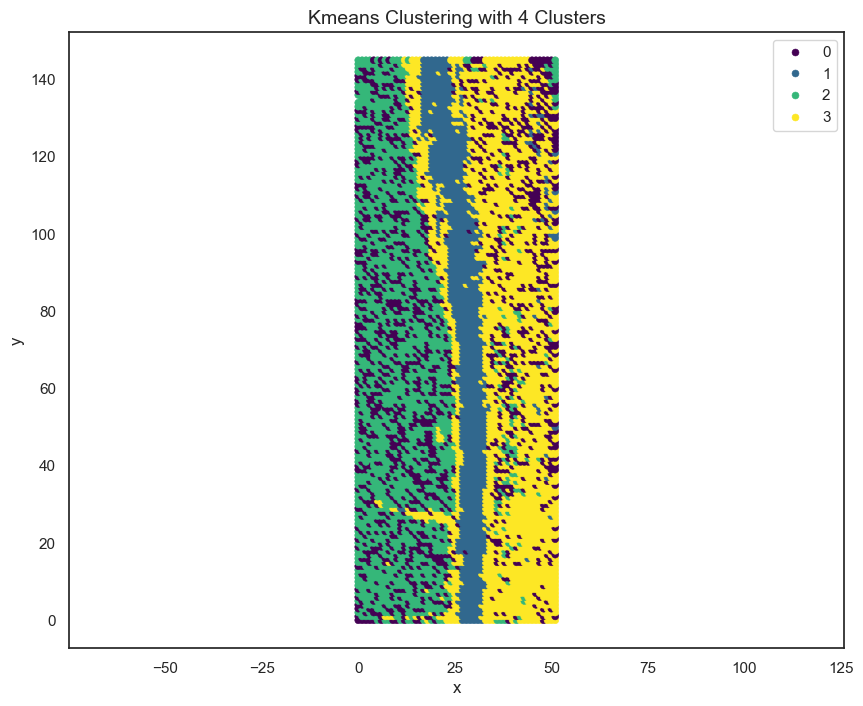

In [ ]:
# Run model
num_clusters = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X_scaled)

# Plot results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='x',
    y='y',
    hue=kmeans.labels_,                      
    palette=my_cmap,                          
    edgecolor=None,
    s=25
)

plt.title(f'Kmeans Clustering with {num_clusters} Clusters', fontsize=14)
plt.axis('equal')
plt.show()